# Part 5 Task: Kdrama Wikipedia Pageviews

For this task, I am looking at patterns in interest in Kdramas using Wikipedia pageviews. My goal is to recreate Graph 1 and Graph 2 from the assignment.

## Table of Content

1. [Plan](#plan)
2. [Load the Kdrama Data](#load-data)
3. [Choose the Dramas](#choose-dramas)
4. [Get Wikipedia Pageviews](#pageviews)
5. [Graph 1: Total Pageviews](#graph-1)
6. [Prepare Data for Graph 2](#prepare-graph-2)
7. [Graph 2: Pageviews Around the Peak](#graph-2)
8. [What I Notice](#reflection)

<a id="plan"></a>
## Plan

1. Load the 2023 Kdrama CSV using pandas.
2. Figure out which dramas are used in the graphs.
3. Get the Wikipedia pageviews for each drama.
4. Add up the total pageviews for each drama.
5. Sort the dramas from most pageviews to least.
6. Make a horizontal bar chart for Graph 1.
7. For Graph 2, find the day each drama had the most pageviews.
8. Compare the days before and after that peak day.
9. Plot the pageviews with the peak day as Day 0.
10. Use fill_between to shade under the lines.

<a id="load-data"></a>

## Load the Kdrama Data

First, I loaded the MyDramaList data for Kdramas released in 2023.

In [51]:
import pandas as pd

df = pd.read_csv('kdramas_2023.csv')

df.head()
df.shape
df.columns
df['Title_English'].head(20)

0                               High Cookie (2023)
1                           Strangers Again (2023)
2                  Hello! This Is Starbucks (2023)
3                                Adult Kids (2023)
4                                  My Demon (2023)
5                           The Matchmakers (2023)
6                             D.P. Season 2 (2023)
7                           Longing for You (2023)
8                                    Intern (2023)
9                                  Why R U? (2023)
10                                   Doona! (2023)
11                         Love to Hate You (2023)
12                  Couple Scandal Season 2 (2023)
13                                     Race (2023)
14                                  Boyhood (2023)
15                    Divorce Attorney Shin (2023)
16        Those Who Pass Through Gimpo City (2023)
17    The Story of Park's Marriage Contract (2023)
18                        Youth on the Road (2023)
19                             

<a id="choose-dramas"></a>

## Choose the Dramas

The assignment graphs use a smaller group of dramas from the full 2023 dataset. I made a list of the Wikipedia page titles for those dramas.

In [52]:
dramas = [
    "The Glory (TV series)",
    "Moving (South Korean TV series)",
    "My Demon",
    "King the Land",
    "Gyeongseong Creature",
    "Twinkling Watermelon",
    "Death's Game",
    "Crash Course in Romance",
    "Welcome to Samdal-ri",
    "Celebrity (South Korean TV series)",
    "A Time Called You",
    "Perfect Marriage Revenge",
    "See You in My 19th Life",
    "The Good Bad Mother",
    "My Lovely Liar",
    "Doona!",
    "Love to Hate You (TV series)",
    "Daily Dose of Sunshine",
    "Destined with You"
]

<a id="pageviews"></a>

## Get Wikipedia Pageviews

I used the `mwviews` library from the Friday Wikipedia tutorial to get daily Wikipedia pageviews for each drama.

In [53]:
from mwviews.api import PageviewsClient

p = PageviewsClient(user_agent="Aayah Kdrama Project")

In [54]:
test = p.article_views(
    'en.wikipedia',
    ['My Demon'],
    start='20220601',
    end='20240601'
)

list(test.items())[:3]

[(datetime.datetime(2022, 6, 1, 0, 0), {'My_Demon': None}),
 (datetime.datetime(2022, 6, 2, 0, 0), {'My_Demon': None}),
 (datetime.datetime(2022, 6, 3, 0, 0), {'My_Demon': None})]

In [55]:
pageviews = {}

for drama in dramas:
    print("Getting:", drama)

    data = p.article_views(
        'en.wikipedia',
        [drama],
        start='20220601',
        end='20240601'
    )

    pageviews[drama] = data

Getting: The Glory (TV series)
Getting: Moving (South Korean TV series)
Getting: My Demon
Getting: King the Land
Getting: Gyeongseong Creature
Getting: Twinkling Watermelon
Getting: Death's Game
Getting: Crash Course in Romance
Getting: Welcome to Samdal-ri
Getting: Celebrity (South Korean TV series)
Getting: A Time Called You
Getting: Perfect Marriage Revenge
Getting: See You in My 19th Life
Getting: The Good Bad Mother
Getting: My Lovely Liar
Getting: Doona!
Getting: Love to Hate You (TV series)
Getting: Daily Dose of Sunshine
Getting: Destined with You


In [56]:
clean_pageviews = {}

for drama in dramas:
    clean_pageviews[drama] = {}

    for date in pageviews[drama]:
        views_dict = pageviews[drama][date]

        views = list(views_dict.values())[0]

        clean_pageviews[drama][date] = views

<a id="graph-1"></a>

## Graph 1: Total Pageviews

For the first graph, I need the total number of Wikipedia pageviews for each drama during the full time period.

In [57]:
totals = {}

for drama in dramas:
    total = 0

    for date in clean_pageviews[drama]:
        views = clean_pageviews[drama][date]

        if views != None:
            total = total + views

    totals[drama] = total
totals

{'The Glory (TV series)': 5437126,
 'Moving (South Korean TV series)': 2891114,
 'My Demon': 2822146,
 'King the Land': 2697595,
 'Gyeongseong Creature': 2081110,
 'Twinkling Watermelon': 2061432,
 "Death's Game": 1963050,
 'Crash Course in Romance': 1488160,
 'Welcome to Samdal-ri': 1460872,
 'Celebrity (South Korean TV series)': 1441608,
 'A Time Called You': 1349860,
 'Perfect Marriage Revenge': 1266164,
 'See You in My 19th Life': 1247697,
 'The Good Bad Mother': 1172570,
 'My Lovely Liar': 1169482,
 'Doona!': 1033094,
 'Love to Hate You (TV series)': 822729,
 'Daily Dose of Sunshine': 559765,
 'Destined with You': 1156}

In [58]:
total_df = pd.DataFrame(
    list(totals.items()),
    columns=['Drama', 'Pageviews']
)

total_df = total_df.sort_values(
    'Pageviews',
    ascending=False
)

total_df

,Drama,Pageviews
0,The Glory (TV series),5437126
1,Moving (South Korean TV series),2891114
2,My Demon,2822146
3,King the Land,2697595
4,Gyeongseong Creature,2081110
5,Twinkling Watermelon,2061432
6,Death's Game,1963050
7,Crash Course in Romance,1488160
8,Welcome to Samdal-ri,1460872
9,Celebrity (South Korean TV series),1441608


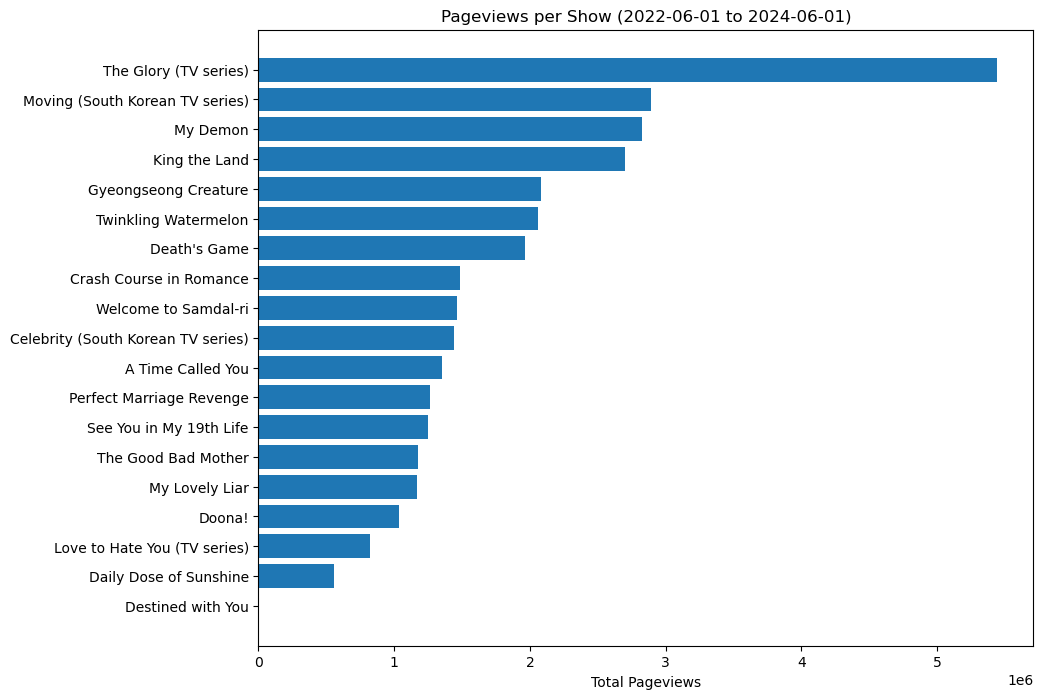

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.barh(
    total_df['Drama'],
    total_df['Pageviews']
)

plt.xlabel('Total Pageviews')
plt.title('Pageviews per Show (2022-06-01 to 2024-06-01)')

plt.gca().invert_yaxis()

plt.show()

<a id="prepare-graph-2"></a>

## Prepare Data for Graph 2

For Graph 2, the dramas need to be lined up based on their peak pageview date. The day with the most pageviews for each drama becomes Day 0. Days before the peak will be negative and days after the peak will be positive.

In [60]:
pageviews_df = pd.DataFrame(clean_pageviews)

pageviews_df.head()

,The Glory (TV series),Moving (South Korean TV series),My Demon,King the Land,Gyeongseong Creature,Twinkling Watermelon,Death's Game,Crash Course in Romance,Welcome to Samdal-ri,Celebrity (South Korean TV series),A Time Called You,Perfect Marriage Revenge,See You in My 19th Life,The Good Bad Mother,My Lovely Liar,Doona!,Love to Hate You (TV series),Daily Dose of Sunshine,Destined with You
2022-06-01,NaN,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02,NaN,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-03,NaN,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-04,NaN,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-05,NaN,212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
pageviews_df.index = pd.to_datetime(pageviews_df.index)

In [62]:
drama = "My Demon"

drama_views = pageviews_df[drama]

drama_views.head()
drama_views = drama_views.dropna()
drama_views.max()

53186.0

In [63]:
peak_date = drama_views.idxmax()

peak_date

Timestamp('2024-01-20 00:00:00')

In [64]:
days_from_peak = (drama_views.index - peak_date).days

days_from_peak[:10]

Index([-367, -366, -362, -348, -340, -338, -330, -325, -324, -323], dtype='int64')

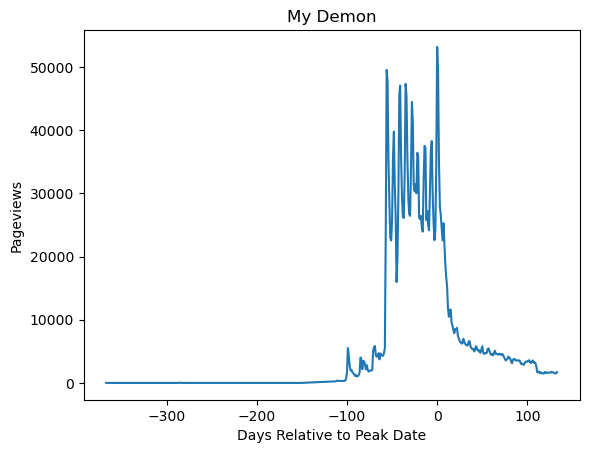

In [65]:
plt.plot(days_from_peak, drama_views)

plt.xlabel('Days Relative to Peak Date')
plt.ylabel('Pageviews')
plt.title('My Demon')

plt.show()

<a id="graph-2"></a>

## Graph 2: Pageviews Around the Peak

Now that I tested the process with one drama, I repeated it for all of the dramas and aligned each one around its peak date.

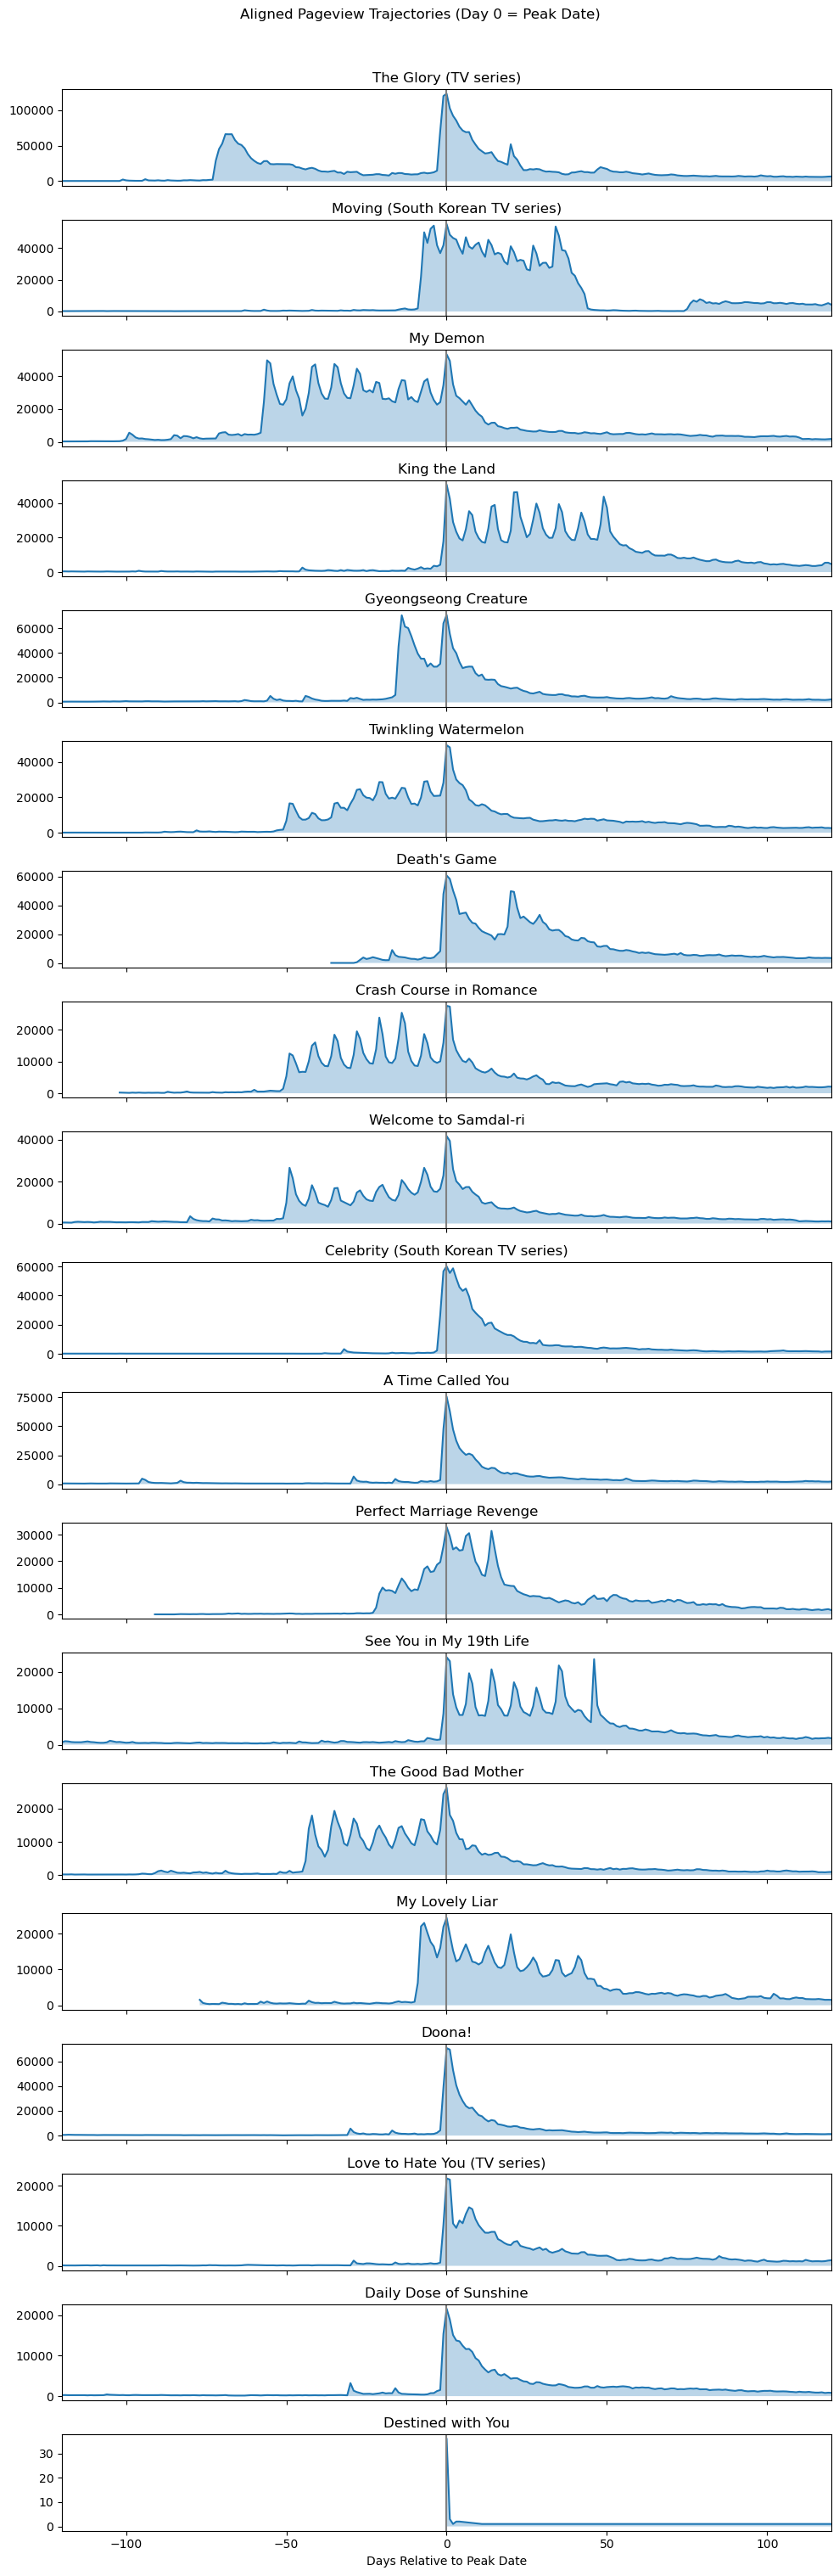

In [66]:
fig, axes = plt.subplots(
    nrows=len(dramas),
    ncols=1,
    figsize=(10, 30),
    sharex=True
)

for i in range(len(dramas)):

    drama = dramas[i]

    drama_views = pageviews_df[drama]
    drama_views = drama_views.dropna()

    peak_date = drama_views.idxmax()

    days_from_peak = (
        drama_views.index - peak_date
    ).days

    axes[i].plot(
        days_from_peak,
        drama_views
    )

    axes[i].fill_between(
        days_from_peak,
        drama_views,
        alpha=0.3
    )

    axes[i].axvline(0, color='gray')

    axes[i].set_xlim(-120, 120)

    axes[i].set_title(drama)

fig.suptitle(
    'Aligned Pageview Trajectories (Day 0 = Peak Date)',
    y=1.01
)
plt.xlabel('Days Relative to Peak Date')
plt.tight_layout()
plt.show()

<a id="reflection"></a>
## What I Notice

### Graph 1

The Glory had way more Wikipedia pageviews than the other dramas. Moving, My Demon, and King the Land were also pretty high, but after The Glory there is a really noticeable drop. Some of the other dramas had way less attention on Wikipedia, especially Destined with You.

### Graph 2

I noticed that the dramas do not all have the same pattern. Some of them, like My Demon, King the Land, and See You in My 19th Life, have a bunch of spikes around the peak instead of just one big spike. Other dramas, like Celebrity, A Time Called You, and Doona!, have one really big spike and then the pageviews drop pretty fast after.

I also noticed that some dramas start getting more attention before the peak, while others mostly blow up right around Day 0. After the peak, most of them seem to slowly lose attention over time.

### Pattern from Graphs 2 and 3

Looking at my Graph 2 and the Graph 3 from the assignment, I think the main pattern is that Kdramas can get attention in different ways. Some of them build interest over time and stay popular for a while, while others get one big burst of attention and then die down pretty quickly.